In [ ]:
import pandas as pd

df = pd.read_csv("/content/employee_performance_with_nan.csv")

df.head()


,Employee_ID,Department,Age,Salary,Projects_Completed,Working_Hours,Performance_Score,Promotion_Status
0,1,Sales,41.0,96794.0,2.0,8.0,40.0,No
1,2,Operations,22.0,44485.0,6.0,9.0,90.0,Yes
2,3,Finance,58.0,109299.0,3.0,9.0,69.0,No
3,4,Operations,56.0,144321.0,7.0,8.0,78.0,Yes
4,5,Operations,57.0,125584.0,4.0,6.0,94.0,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         4000 non-null   int64  
 1   Department          4000 non-null   object 
 2   Age                 3800 non-null   float64
 3   Salary              3800 non-null   float64
 4   Projects_Completed  3800 non-null   float64
 5   Working_Hours       3800 non-null   float64
 6   Performance_Score   3800 non-null   float64
 7   Promotion_Status    4000 non-null   object 
dtypes: float64(5), int64(1), object(2)
memory usage: 250.1+ KB


In [ ]:
df.describe()

,Employee_ID,Age,Salary,Projects_Completed,Working_Hours,Performance_Score
count,4000.000000,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000
mean,2000.500000,40.090000,85522.731842,5.032895,8.457368,69.471053
std,1154.844867,11.082561,37667.085928,2.268087,1.684912,17.294903
min,1.000000,21.000000,20002.000000,0.000000,6.000000,40.000000
25%,1000.750000,31.000000,53031.500000,3.000000,7.000000,55.000000
50%,2000.500000,40.000000,86749.500000,5.000000,8.000000,69.000000
75%,3000.250000,49.000000,118069.000000,6.000000,10.000000,84.000000
max,4000.000000,59.000000,149994.000000,15.000000,11.000000,99.000000


In [ ]:
df.isnull().sum()


,0
Employee_ID,0
Department,0
Age,200
Salary,200
Projects_Completed,200
Working_Hours,200
Performance_Score,200
Promotion_Status,0


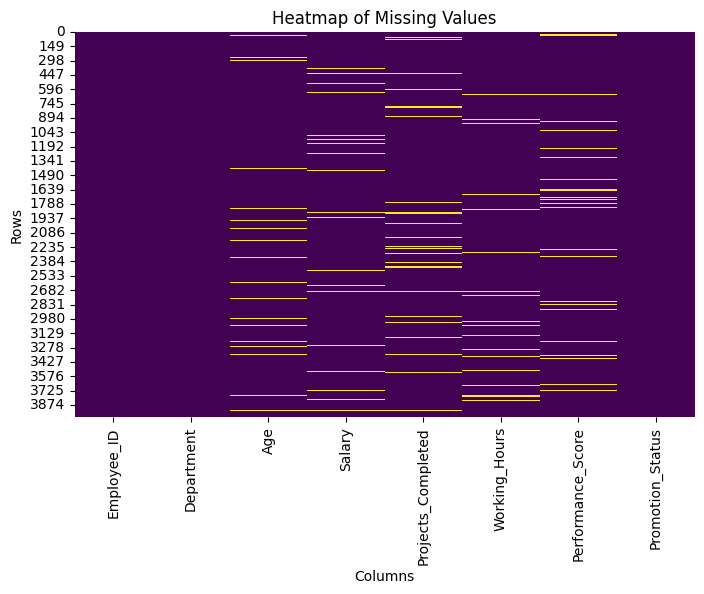

In [ ]:
#Creating Null Value Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Heatmap of Missing Values")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


In [ ]:
null_percentage = (df.isnull().sum() / len(df)) * 100
null_percentage


,0
Employee_ID,0.0
Department,0.0
Age,5.0
Salary,5.0
Projects_Completed,5.0
Working_Hours,5.0
Performance_Score,5.0
Promotion_Status,0.0


The dataset contains approximately 5% missing values in numerical features such as Age, Salary, Projects_Completed, Working_Hours, and Performance_Score, while categorical variables have no missing values.
Since the proportion of missing data is small, mean imputation is used to handle missing values without significantly affecting the data distribution.

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

num_cols, cat_cols


(Index(['Employee_ID', 'Age', 'Salary', 'Projects_Completed', 'Working_Hours',
        'Performance_Score'],
       dtype='object'),
 Index(['Department', 'Promotion_Status'], dtype='object'))

In [ ]:
df[['Age', 'Salary', 'Projects_Completed',
    'Working_Hours', 'Performance_Score']].skew()


,0
Age,0.000539
Salary,-0.031179
Projects_Completed,0.478950
Working_Hours,0.048790
Performance_Score,-0.002717


In [ ]:
num_cols = ['Age', 'Salary', 'Projects_Completed',
            'Working_Hours', 'Performance_Score']

df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


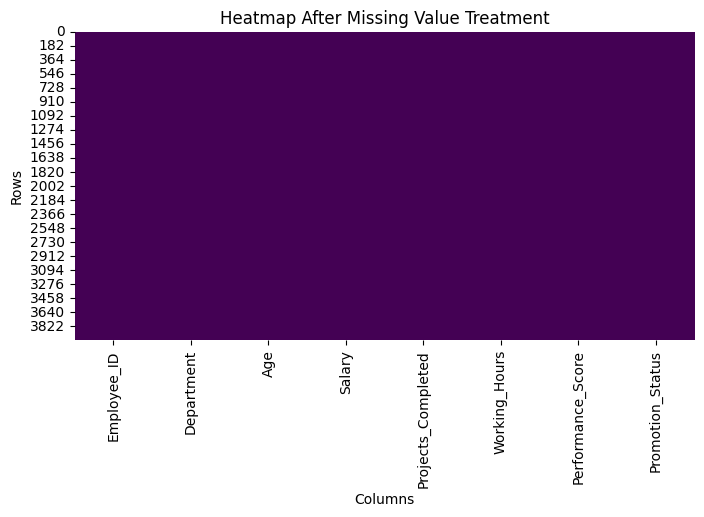

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis')

plt.title("Heatmap After Missing Value Treatment")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


#EDA

In [ ]:
df.describe()


,Employee_ID,Age,Salary,Projects_Completed,Working_Hours,Performance_Score
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,2000.500000,40.090000,85522.731842,5.032895,8.457368,69.471053
std,1154.844867,10.801874,36713.092414,2.210643,1.642239,16.856875
min,1.000000,21.000000,20002.000000,0.000000,6.000000,40.000000
25%,1000.750000,31.000000,54556.750000,3.000000,7.000000,56.000000
50%,2000.500000,40.090000,85522.731842,5.000000,8.457368,69.471053
75%,3000.250000,49.000000,116325.500000,6.000000,10.000000,83.000000
max,4000.000000,59.000000,149994.000000,15.000000,11.000000,99.000000


Descriptive statistical analysis was performed after handling missing values.
The dataset consists of 4000 complete observations. Employees have an average age of approximately 40 years and an average salary of ₹85,523, with noticeable variation in compensation.
Performance scores range from 40 to 99, indicating diversity in employee performance levels.

In [ ]:
mean_salary = df['Salary'].mean()
median_salary = df['Salary'].median()
mode_salary = df['Salary'].mode()[0]

mean_salary, median_salary, mode_salary


(np.float64(85522.73184210525),
 85522.73184210526,
 np.float64(85522.73184210526))

The mean, median, and mode of employee salary are approximately equal at ₹85,523.
This indicates a symmetric salary distribution with no significant skewness, suggesting that the average salary is a reliable measure of central tendency.

#Measure of Dispersion (Salary)

In [ ]:
#Variance & Standard Deviation (Salary)
salary_variance = df['Salary'].var()
salary_std = df['Salary'].std()

salary_variance, salary_std


(1347851154.6190922, 36713.09241427494)

The standard deviation of salary is approximately ₹36,713, indicating substantial variability in employee compensation.
This suggests the presence of employees across different experience and responsibility levels within the organization.

#Salary Distribution & Outlier Detection

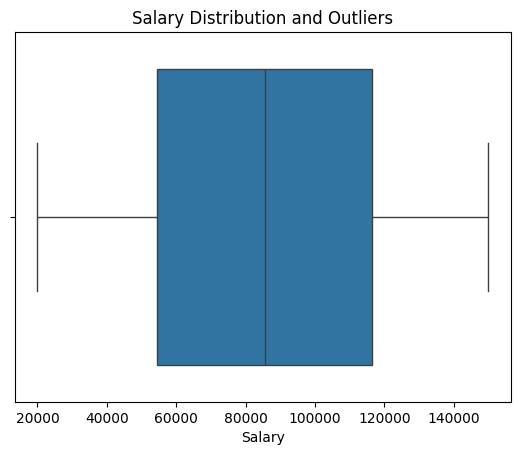

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Salary'])
plt.title("Salary Distribution and Outliers")
plt.show()


The salary boxplot shows no extreme outliers, indicating a clean and reliable salary distribution. The median lies near the center of the interquartile range, confirming a symmetric distribution. The wide spread reflects significant variation in salaries across employees.

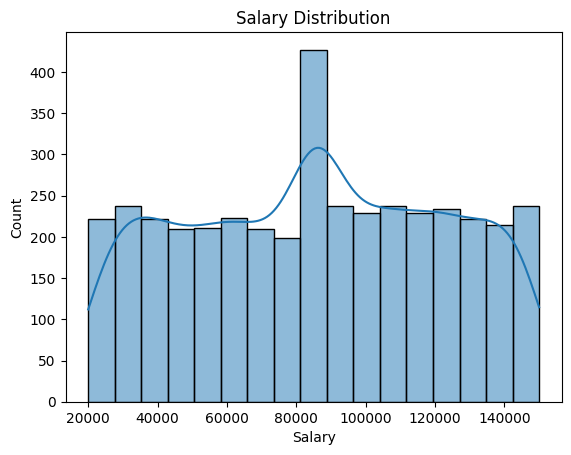

In [ ]:
sns.histplot(df['Salary'], kde=True)
plt.title("Salary Distribution")
plt.show()


The salary histogram with KDE shows an approximately symmetric distribution centered around ₹85,000.
This confirms the absence of skewness and supports the use of mean as a reliable measure of central tendency.

#Performance Score Analysis

---Histogram + KDE



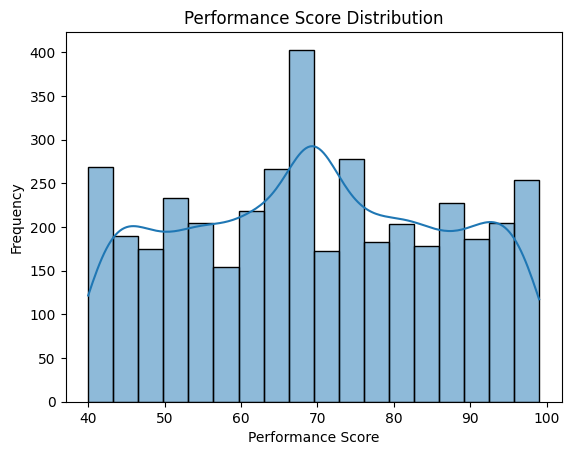

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['Performance_Score'], kde=True)
plt.title("Performance Score Distribution")
plt.xlabel("Performance Score")
plt.ylabel("Frequency")
plt.show()


The performance score distribution is approximately symmetric and centered around a score of 70.
The absence of extreme skewness indicates that performance scores are well balanced, making them suitable for probability and promotion analysis.

#Q-Q Plot (Normality Check)

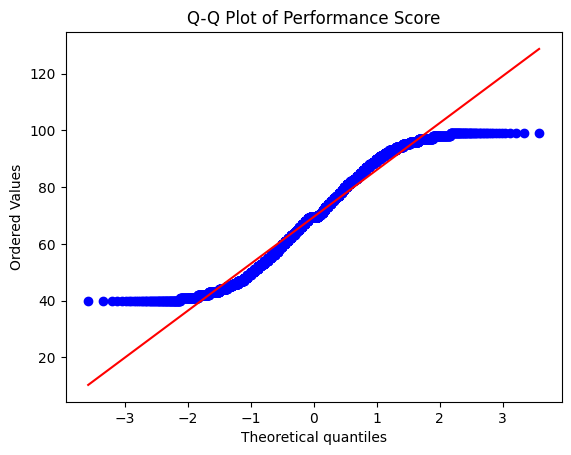

In [ ]:
from scipy import stats

stats.probplot(df['Performance_Score'], dist="norm", plot=plt)
plt.title("Q-Q Plot of Performance Score")
plt.show()


The Q–Q plot shows that performance scores closely follow the normal reference line in the central region, with minor deviations at the tails.
This indicates that the performance scores are approximately normally distributed, which is acceptable for further statistical and probability-based analysis.

#Probability & Promotion Analysis

In [ ]:
#Overall Promotion Probability
df['Promotion_Status'].value_counts(normalize=True)


,proportion
Promotion_Status,
No,0.58625
Yes,0.41375


The probability of an employee getting promoted is approximately 41.38%, while 58.62% of employees are not promoted.
This indicates that promotions are selective and likely dependent on performance and other factors.

#Contingency Table (Department × Promotion)

In [ ]:
pd.crosstab(df['Department'], df['Promotion_Status'])


Promotion_Status,No,Yes
Department,,
Finance,463,314
HR,501,328
IT,452,316
Operations,463,346
Sales,466,351


The contingency table shows that promotion counts vary across departments.
Sales and Operations have comparatively higher promotion counts, while HR shows fewer promotions.
This indicates that promotion decisions may be influenced by departmental roles and performance requirements.

#Conditional Probability

In [ ]:
high_perf = df[df['Performance_Score'] > 80]

high_perf['Promotion_Status'].value_counts(normalize=True)


,proportion
Promotion_Status,
Yes,1.0


The conditional probability analysis shows that all employees with a performance score greater than 80 were promoted, resulting in a probability of 1.0.
This indicates a strong relationship between high performance and promotion decisions, highlighting performance score as a critical factor for promotion.

#KEY INSIGHTS SECTION
The average employee salary is approximately ₹85,523, with significant variation across employees.

Salary distribution is symmetric with no extreme outliers, indicating a balanced compensation structure.

Performance scores are approximately normally distributed, making them suitable for statistical analysis.

About 41.38% of employees were promoted, indicating selective promotion practices.

Employees with a performance score above 80 have a 100% probability of promotion, showing a strong performance–promotion relationship.

#Correlation Analysis
Shows relationships between numerical variables and strengthens insights.

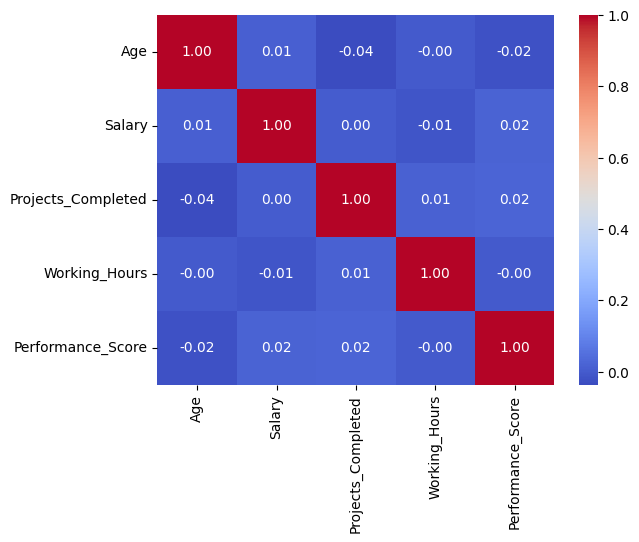

In [ ]:
num_df = df[['Age', 'Salary', 'Projects_Completed',
             'Working_Hours', 'Performance_Score']]

sns.heatmap(num_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.show()


he correlation heatmap shows that numerical features have very weak linear relationships with each other.
This indicates low multicollinearity in the dataset.
Despite weak correlations, promotion outcomes are strongly driven by a performance score threshold, suggesting a rule-based rather than linear decision process.

#Department-wise Promotion Rate

In [ ]:
dept_promo_rate = (
    df.groupby('Department')['Promotion_Status']
    .apply(lambda x: (x == 'Yes').mean())
)

dept_promo_rate


,Promotion_Status
Department,
Finance,0.404118
HR,0.395657
IT,0.411458
Operations,0.427689
Sales,0.429621


Department-wise promotion rate analysis shows that promotion percentages are relatively consistent across departments, ranging from approximately 39% to 43%.
Sales and Operations exhibit slightly higher promotion rates, suggesting a stronger performance-driven promotion culture in these departments.
Overall, the organization demonstrates balanced promotion practices across departments.

#Performance Bands Analysis

In [ ]:
bins = [0, 60, 80, 100]
labels = ['Low', 'Medium', 'High']

df['Performance_Level'] = pd.cut(df['Performance_Score'], bins=bins, labels=labels)


In [ ]:
pd.crosstab(df['Performance_Level'], df['Promotion_Status'], normalize='index')


Promotion_Status,No,Yes
Performance_Level,,
Low,1.0000,0.0000
Medium,0.6945,0.3055
High,0.0000,1.0000


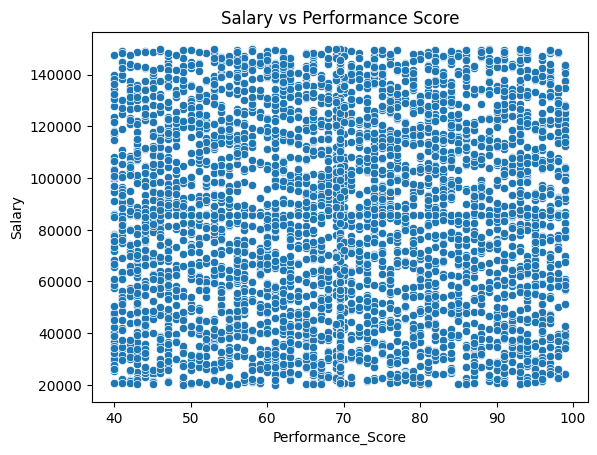

In [ ]:
sns.scatterplot(x=df['Performance_Score'], y=df['Salary'])
plt.title("Salary vs Performance Score")
plt.show()


The scatter plot of salary versus performance score shows no clear linear relationship between the two variables.
Salaries are widely distributed across all performance levels, indicating that compensation is influenced by factors other than performance score alone.
While performance strongly determines promotion decisions, it does not directly impact salary levels.

#KPI Dashboard Summary



In [ ]:
df[['Salary', 'Performance_Score', 'Projects_Completed']].agg(['mean', 'median', 'std'])


,Salary,Performance_Score,Projects_Completed
mean,85522.731842,69.471053,5.032895
median,85522.731842,69.471053,5.000000
std,36713.092414,16.856875,2.210643


Key performance indicators show that the average employee salary is approximately ₹85,523 with substantial variability, reflecting diverse roles and experience levels.
Performance scores are centered around 69 with a reasonable spread, enabling effective differentiation between employee performance levels.
Employees complete an average of five projects, indicating consistent productivity across the organization.